# **Problema 2: Integración numérica de flujos**

Considere los siguientes campos de velocidad dependientes del tiempo $\mathbf{u}(\mathbf{x}, t)$ en el caso bidimensional $\mathbf{x} = x~\mathbf{\hat{x}}+ y~\mathbf{\hat{y}}$.
En cada caso, adimensionalice los campos y calcule numéricamente las trayectorias y la evolución de las líneas de corriente eligiendo puntos de colocación iniciales más apropiados para el flujo en cuestión:

(i) Una fuente lineal de caudal constante $Q$ superpuesta a una corriente uniforme cuya velocidad aumenta linealmente con el tiempo $U(t) = \gamma_0 t$.

(ii) Una fuente lineal de caudal constante $Q$ superpuesta a un torbellino cuya circulación $\Gamma$ decrece exponencialmente con un tiempo característico $\tau$.
_Ayuda: Tras adimensionalizar quedará un parámetro libre. Bárralo para estudiar los distintos regímenes._

(iii) Una fuente lineal de caudal constante $Q$ superpuesta a una corriente uniforme oscilante con velocidad $U(t) = U_0\cos(\omega t)$.


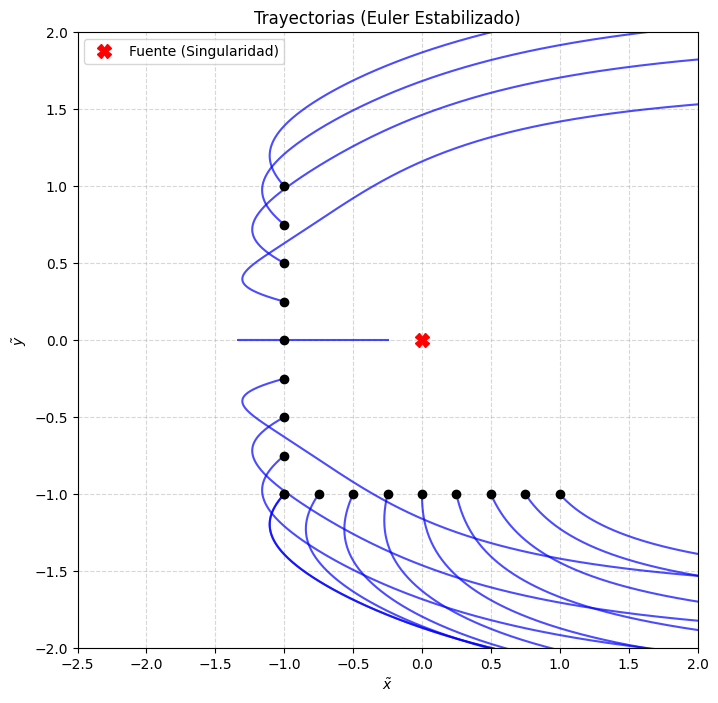

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 2. Motor Numérico y Modelo Físico ---
def esquema(X, u, t, dt):
    return X + u(X, t) * dt

def linea_de_corriente(l0, u, t, N, ds):
    d = l0.shape[0]
    s = np.arange(0, N+1)*ds
    ls = np.zeros((N+1, d))
    ls[0] = l0

    u_lc = lambda x, _: u(x, t)
    for j in range(N):
        ls[j+1] = esquema(ls[j], u_lc, t, ds)
    return s, ls

def campo_adimensional(X, t):
    x, y = X[0], X[1]
    r2 = x**2 + y**2
    if r2 < 1e-4: # Manejo de singularidad
        return np.array([0.0, 0.0])
    u_x = (x / r2) + t
    u_y = (y / r2)
    return np.array([u_x, u_y])

# --- 3. Condiciones Iniciales Estratégicas ---
thetas = np.linspace(0, 2*np.pi, 20, endpoint=False)
radio_emision = 0.05
l0s_fuente = [np.array([radio_emision*np.cos(th), radio_emision*np.sin(th)]) for th in thetas]
l0s_borde = [np.array([-1.5, y]) for y in np.linspace(-1.5, 1.5, 15)]
l0s = np.array(l0s_fuente + l0s_borde)

N_pasos = 400
ds = 0.01

# --- 4. Función de renderizado ---
def graficar_frame(t_val):
    plt.figure(figsize=(7, 7))

    for l0 in l0s:
        _, ls = linea_de_corriente(l0, campo_adimensional, t_val, N_pasos, ds)
        plt.plot(ls[:,0], ls[:,1], color='blue', alpha=0.6)

    # Marcador de la singularidad como PUNTO ('ro')
    plt.plot(0, 0, 'ro', markersize=6, label='Fuente (Singularidad)')

    plt.xlim(-1.5, 1.5)
    plt.ylim(-1.5, 1.5)
    plt.xlabel(r'Coordenada adimensional $\tilde{x}$')
    plt.ylabel(r'Coordenada adimensional $\tilde{y}$')
    plt.title(f'Evolución Topológica de Líneas de Corriente a $\\tilde{{t}} = {t_val:.2f}$')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()



# Ahora calculamos las trayectorias..

import numpy as np
import matplotlib.pyplot as plt

# --- Motor Numérico Original ---
def esquema(X, u, t, dt):
    return X + u(X, t) * dt

def trayectoria(X0, u, N, dt):
    d = X0.shape[0]
    ts = np.arange(0, N+1)*dt
    Xs = np.zeros((N+1, d))
    Xs[0] = X0
    for j in range(N):
        Xs[j+1] = esquema(Xs[j], u, ts[j], dt)
    return ts, Xs

# --- Campo Físico Estabilizado ---
def campo_adimensional_seguro(X, t):
    x, y = X[0], X[1]
    r2 = x**2 + y**2

    # Parámetro de suavización (Softening) para evitar la explosión de Euler
    epsilon = 0.05
    denom = r2 + epsilon**2

    u_x = (x / denom) + t
    u_y = (y / denom)
    return np.array([u_x, u_y])

# --- Tu Esqueleto Corregido ---
# Aumentamos N a 400 para darle tiempo a la corriente de arrastrar
# a las partículas de vuelta hacia el dominio visible.
N = 400
dt = 1e-2

# Barrera de inyección en L
l0s = [[-1, a] for a in np.linspace(-1, 1, 9)]
l0s = l0s + [[a, -1] for a in np.linspace(-1, 1, 9)]
l0s = np.array(l0s)

plt.figure(figsize=(8, 8))

for i in range(l0s.shape[0]):
    # Llamamos a tu integrador
    t_arr, Xs = trayectoria(l0s[i], campo_adimensional_seguro, N, dt)

    # Graficamos según tu convención
    plt.plot(Xs[0,0], Xs[0,1], "ko", zorder=3)
    plt.plot(Xs[:,0], Xs[:,1], "b-", alpha=0.7)

# Marcamos el origen (la fuente suavizada)
plt.plot(0, 0, 'rX', markersize=10, label='Fuente (Singularidad)')

# Ampliamos la ventana para poder ver el "turnaround" (el retroceso)
plt.xlim(-2.5, 2)
plt.ylim(-2, 2)
plt.xlabel(r'$\tilde{x}$')
plt.ylabel(r'$\tilde{y}$')
plt.title('Trayectorias (Euler Estabilizado)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()




Esto vino despues

In [2]:
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass # Por si lo corres fuera de Colab en el futuro

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# --- 2. Motor Numérico y Modelo Físico ---
def esquema(X, u, t, dt):
    return X + u(X, t) * dt

def linea_de_corriente(l0, u, t, N, ds):
    d = l0.shape[0]
    s = np.arange(0, N+1)*ds
    ls = np.zeros((N+1, d))
    ls[0] = l0

    u_lc = lambda x, _: u(x, t)
    for j in range(N):
        ls[j+1] = esquema(ls[j], u_lc, t, ds)
    return s, ls

def campo_adimensional(X, t):
    x, y = X[0], X[1]
    r2 = x**2 + y**2
    if r2 < 1e-4: # Manejo de singularidad
        return np.array([0.0, 0.0])
    u_x = (x / r2) + t
    u_y = (y / r2)
    return np.array([u_x, u_y])

# --- 3. Condiciones Iniciales Estratégicas ---
thetas = np.linspace(0, 2*np.pi, 20, endpoint=False)
radio_emision = 0.05
l0s_fuente = [np.array([radio_emision*np.cos(th), radio_emision*np.sin(th)]) for th in thetas]
l0s_borde = [np.array([-1.5, y]) for y in np.linspace(-1.5, 1.5, 15)]
l0s = np.array(l0s_fuente + l0s_borde)

N_pasos = 400
ds = 0.01

# --- 4. Motor de Renderizado ---
# Esta función recalcula y redibuja la física para un t_val específico
def graficar_frame(t_val):
    plt.figure(figsize=(7, 7))

    for l0 in l0s:
        _, ls = linea_de_corriente(l0, campo_adimensional, t_val, N_pasos, ds)
        plt.plot(ls[:,0], ls[:,1], color='blue', alpha=0.6)

    # Marcador de la singularidad como PUNTO ('ro')
    plt.plot(0, 0, 'ro', markersize=6, label='Fuente (Singularidad)')

    plt.xlim(-1.5, 1.5)
    plt.ylim(-1.5, 1.5)
    plt.xlabel(r'Coordenada adimensional $\tilde{x}$')
    plt.ylabel(r'Coordenada adimensional $\tilde{y}$')
    plt.title(f'Evolución Topológica de Líneas de Corriente a $\\tilde{{t}} = {t_val:.2f}$')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show() # Fundamental: ipywidgets intercepta este show() para actualizar el cuadro

# --- 5. Interfaz Interactiva ---
deslizador = FloatSlider(value=0.0, min=0.0, max=5.0, step=0.1, description='Tiempo t:')
interact(graficar_frame, t_val=deslizador)

interactive(children=(FloatSlider(value=0.0, description='Tiempo t:', max=5.0), Output()), _dom_classes=('widg…

<function __main__.graficar_frame(t_val)>

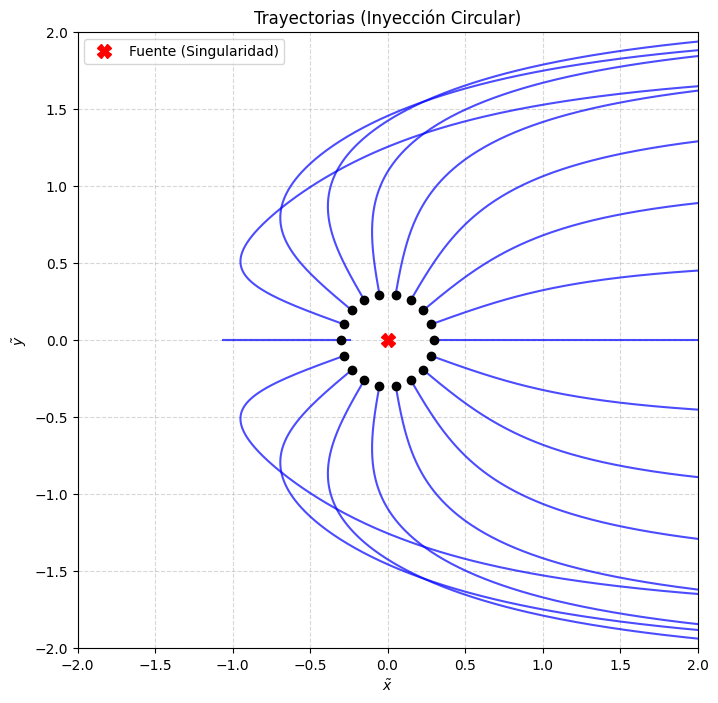

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- Motor Numérico Original ---
def esquema(X, u, t, dt):
    return X + u(X, t) * dt

def trayectoria(X0, u, N, dt):
    d = X0.shape[0]
    ts = np.arange(0, N+1)*dt
    Xs = np.zeros((N+1, d))
    Xs[0] = X0
    for j in range(N):
        Xs[j+1] = esquema(Xs[j], u, ts[j], dt)
    return ts, Xs

# --- Campo Físico Estabilizado ---
def campo_adimensional_seguro(X, t):
    x, y = X[0], X[1]
    r2 = x**2 + y**2

    # Parámetro de suavización (Softening) para evitar la explosión de Euler
    epsilon = 0.05
    denom = r2 + epsilon**2

    u_x = (x / denom) + t
    u_y = (y / denom)
    return np.array([u_x, u_y])

# --- Esqueleto Modificado: Inyección Circular ---
N = 400
dt = 1e-2

# Generamos un anillo de 18 partículas alrededor de la fuente
radio_inyeccion = 0.3
thetas = np.linspace(0, 2*np.pi, 18, endpoint=False)
l0s = np.array([[radio_inyeccion * np.cos(th), radio_inyeccion * np.sin(th)] for th in thetas])

plt.figure(figsize=(8, 8))

for i in range(l0s.shape[0]):
    # Llamamos al integrador lagrangiano
    t_arr, Xs = trayectoria(l0s[i], campo_adimensional_seguro, N, dt)

    # Graficamos el punto inicial (el círculo negro) y la trayectoria azul
    plt.plot(Xs[0,0], Xs[0,1], "ko", zorder=3)
    plt.plot(Xs[:,0], Xs[:,1], "b-", alpha=0.7)

# Marcamos el origen (la fuente suavizada)
plt.plot(0, 0, 'rX', markersize=10, zorder=4, label='Fuente (Singularidad)')

# Ajustamos los límites de la ventana de visualización
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.xlabel(r'$\tilde{x}$')
plt.ylabel(r'$\tilde{y}$')
plt.title('Trayectorias (Inyección Circular)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

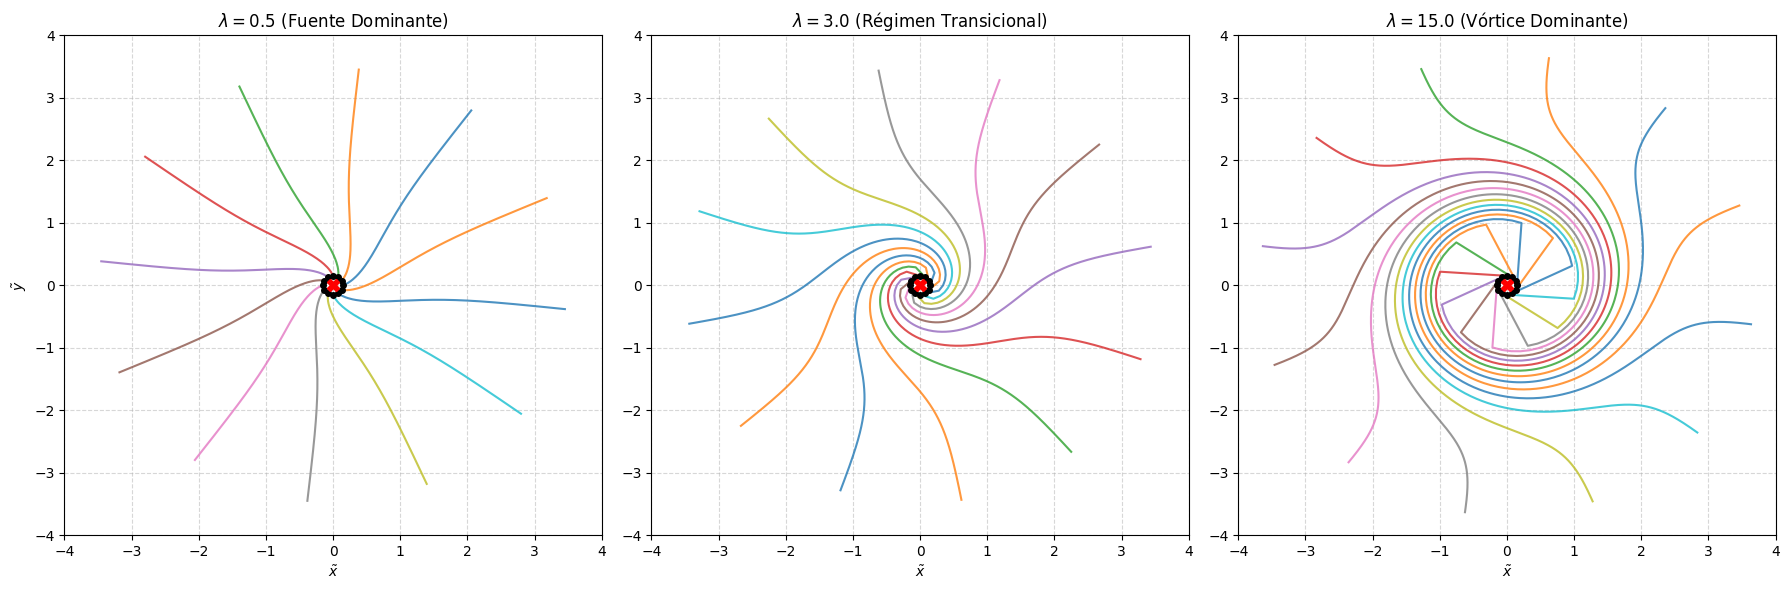

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Motor de Integración ---
def esquema(X, u, t, dt):
    return X + u(X, t) * dt

def trayectoria(X0, u, N, dt):
    d = X0.shape[0]
    ts = np.arange(0, N+1)*dt
    Xs = np.zeros((N+1, d))
    Xs[0] = X0
    for j in range(N):
        Xs[j+1] = esquema(Xs[j], u, ts[j], dt)
    return ts, Xs

# --- 2. Modelo Físico Parametrizado ---
def campo_ii(X, t, lam):
    """
    Campo adimensional: Fuente + Torbellino decadente.
    lam (lambda) es el parámetro libre: (Fuerza del Vórtice / Caudal).
    """
    x, y = X[0], X[1]
    r2 = x**2 + y**2

    # Softening para la singularidad central
    denom = r2 + 1e-4

    # Término de fuente (radial)
    u_r_x = x / denom
    u_r_y = y / denom

    # Término de vórtice (azimutal) con decaimiento temporal
    decaimiento = np.exp(-t)
    u_theta_x = (-y / denom) * decaimiento
    u_theta_y = (x / denom) * decaimiento

    # Superposición
    u_x = u_r_x + lam * u_theta_x
    u_y = u_r_y + lam * u_theta_y

    return np.array([u_x, u_y])

# --- 3. Parámetros de Simulación e Inyección ---
N_pasos = 600
dt = 0.01

# Inyección radial: un pequeño anillo de partículas cerca del origen
radio_inyeccion = 0.15
thetas = np.linspace(0, 2*np.pi, 12, endpoint=False)
l0s = np.array([[radio_inyeccion * np.cos(th), radio_inyeccion * np.sin(th)] for th in thetas])

# Definimos los regímenes que queremos estudiar
lambdas_a_evaluar = [0.5, 3.0, 15.0]
titulos = [
    r'$\lambda = 0.5$ (Fuente Dominante)',
    r'$\lambda = 3.0$ (Régimen Transicional)',
    r'$\lambda = 15.0$ (Vórtice Dominante)'
]

# --- 4. Bucle de Integración y Visualización ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, lam in enumerate(lambdas_a_evaluar):
    ax = axes[idx]

    # Envolvemos el campo con una función lambda de Python para fijar el parámetro lam
    # y que la función 'trayectoria' solo vea las variables X y t.
    campo_fijado = lambda X, t: campo_ii(X, t, lam)

    for i in range(l0s.shape[0]):
        ts, Xs = trayectoria(l0s[i], campo_fijado, N_pasos, dt)
        ax.plot(Xs[0,0], Xs[0,1], "ko", markersize=4, zorder=3) # Punto de inicio
        ax.plot(Xs[:,0], Xs[:,1], "-", alpha=0.8)               # Trayectoria

    ax.plot(0, 0, 'rX', markersize=8, zorder=4) # Singularidad

    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_xlabel(r'$\tilde{x}$')
    if idx == 0: ax.set_ylabel(r'$\tilde{y}$')
    ax.set_title(titulos[idx])
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# --- 1. Funciones de Integración Numérica ---
def esquema(X, u, t, dt):
    return X + u(X, t) * dt

def linea_de_corriente(l0, u, t, N, ds):
    d = l0.shape[0]
    s = np.arange(0, N+1)*ds
    ls = np.zeros((N+1, d))
    ls[0] = l0
    u_lc = lambda x, _: u(x, t)
    for j in range(N):
        ls[j+1] = esquema(ls[j], u_lc, t, ds)
    return s, ls

# --- 2. Campo Vectorial Adimensionalizado (Ítem ii) ---
def campo_ii(X, t):
    """Fuente + Torbellino decadente (lambda = 5.0)"""
    lam = 5.0
    x, y = X[0], X[1]
    r2 = x**2 + y**2
    denom = r2 + 1e-4  # Softening

    u_r_x = x / denom
    u_r_y = y / denom

    decaimiento = np.exp(-t)
    u_theta_x = (-y / denom) * decaimiento
    u_theta_y = (x / denom) * decaimiento

    u_x = u_r_x + lam * u_theta_x
    u_y = u_r_y + lam * u_theta_y
    return np.array([u_x, u_y])

# --- 3. Tu Esqueleto de Animación (con sintaxis corregida) ---
def evolucionar_lineas(l0s, ts, u, N, ds, ext=None, figsize=None):
    n = l0s.shape[0]   # Cantidad de líneas de corriente
    m = ts.shape[0]    # Cantidad de tiempos (fotogramas)
    ls = np.zeros((m, n, N+1, 2))

    for i in range(m):
        for j in range(n):
            _, ls[i,j] = linea_de_corriente(l0s[j], u, ts[i], N, ds)

    xs = ls[:,:,:,0]
    ys = ls[:,:,:,1]

    if ext is None:
        extent = [np.min(np.array(xs)), np.max(np.array(xs)),
                  np.min(np.array(ys)), np.max(np.array(ys))]
    else:
        extent = ext

    # Guardo el estado de plt
    params_viejos = plt.rcParams.copy() # Corrección para evitar modificar el original
    plt.rc('animation', html='jshtml')

    fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)
    plt.close()  # Cerrar la figura, animation va a crear la suya propia

    # Inicializo las curvas
    plots = [ ax.plot([], [], "b-")[0] for i in range(n) ]
    dots  = [ ax.plot([], [], "ko")[0] for i in range(n) ]
    ax.set_title("$t=0$")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    def init():
        sup = 0
        for i, (x, y) in enumerate(zip(xs[0], ys[0])):
            dots[i].set_xdata([x[0]])
            dots[i].set_ydata([y[0]])
            sup = max(sup, max(np.max(np.abs(x)), np.max(np.abs(y))))

        ax.set_aspect('equal')
        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])
        return plots + dots

    def actualizar(t):
        print(f"\rCalculando fotograma {t+1} de {m}", end="")
        for i, (x, y) in enumerate(zip(xs[t], ys[t])):
            plots[i].set_xdata(x)
            plots[i].set_ydata(y)
        ax.set_title(f"Líneas de Corriente a $t={ts[t]:.2f}$")
        return plots + dots

    anim = animation.FuncAnimation(fig, actualizar, init_func=init,
                                   frames=range(0, m), blit=True, repeat=True)

    # Restauro el estado de plt (Corrección de sintaxis)
    plt.rcParams.update(params_viejos)

    return anim

# --- 4. Ejecución del Programa ---
# Inyectamos en un anillo cercano a la singularidad
radios = 0.1
thetas = np.linspace(0, 2*np.pi, 20, endpoint=False)
l0s = np.array([[radios * np.cos(th), radios * np.sin(th)] for th in thetas])

# Tiempos físicos a evaluar (40 fotogramas desde t=0 hasta t=4)
ts = np.linspace(0, 4.0, 40)

# Parámetros espaciales
N = 300
ds = 0.02
limites = [-3.5, 3.5, -3.5, 3.5]

# Generar la animación
animacion = evolucionar_lineas(l0s, ts, campo_ii, N, ds, ext=limites, figsize=(6,6))

# Mostrar en Colab/Jupyter
HTML(animacion.to_jshtml())

Calculando fotograma 40 de 40

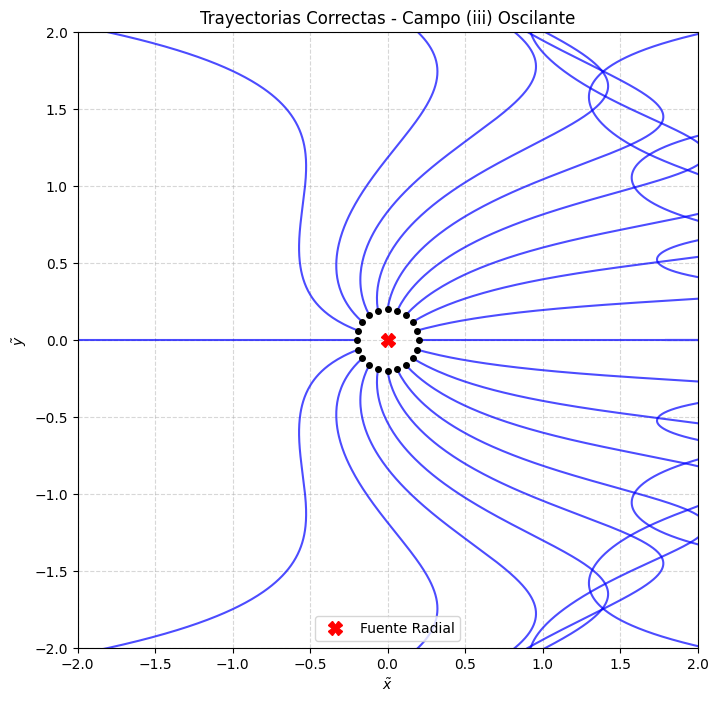

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Motor de Integración (Tu esqueleto exacto) ---
def esquema(X, u, t, dt):
    return X + u(X, t) * dt

def trayectoria(X0, u, N, dt):
    d = X0.shape[0]
    ts = np.arange(0, N+1)*dt
    Xs = np.zeros((N+1, d))
    Xs[0] = X0
    for j in range(N):
        Xs[j+1] = esquema(Xs[j], u, ts[j], dt)
    return ts, Xs

# --- 2. Campo Adimensional ---
def campo_iii(X, t):
    x, y = X[0], X[1]
    r2 = x**2 + y**2

    # Corte de seguridad: si la partícula cae exactamente en el centro geométrico,
    # evitamos que el integrador divida por cero y explote.
    if r2 < 1e-4:
        return np.array([0.0, 0.0])

    u_x = (x / r2) + np.cos(t) # Asumimos S=1 (frecuencia natural)
    u_y = (y / r2)
    return np.array([u_x, u_y])

# --- 3. Puntos Iniciales Apropiados (Anillo central) ---
# Reemplazamos la "L" por un anillo de radio 0.2 alrededor de la fuente
radio = 0.2
thetas = np.linspace(0, 2*np.pi, 20, endpoint=False)
l0s = np.array([[radio * np.cos(th), radio * np.sin(th)] for th in thetas])

# Parámetros de tiempo
N = 600   # Aumentamos N un poco para ver al menos un par de oscilaciones del coseno
dt = 1e-2

# --- 4. Graficación ---
plt.figure(figsize=(8, 8))

for i in range(l0s.shape[0]):
    t_arr, Xs = trayectoria(l0s[i], campo_iii, N, dt)
    plt.plot(Xs[0,0], Xs[0,1], "ko", markersize=4, zorder=3) # Punto inicial
    plt.plot(Xs[:,0], Xs[:,1], "b-", alpha=0.7)              # Trayectoria

plt.plot(0, 0, 'rX', markersize=10, zorder=4, label='Fuente Radial')

# Ampliamos la ventana un poco para ver la trayectoria completa
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.xlabel(r'$\tilde{x}$')
plt.ylabel(r'$\tilde{y}$')
plt.title('Trayectorias Correctas - Campo (iii) Oscilante')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

def esquema(X, u, t, dt):
    return X + u(X, t) * dt

def linea_de_corriente(l0, u, t, N, ds):
    """Integra la geometría congelando el tiempo t"""
    d = l0.shape[0]
    s = np.arange(0, N+1)*ds
    ls = np.zeros((N+1, d))
    ls[0] = l0
    u_lc = lambda x, _: u(x, t)
    for j in range(N):
        ls[j+1] = esquema(ls[j], u_lc, t, ds)
    return s, ls


def campo_iii_euleriano(X, t):
    """Fuente + Corriente Oscilante en x"""
    S = 1.0 # Parámetro adimensional de frecuencia
    x, y = X[0], X[1]
    r2 = x**2 + y**2


    denom = r2 + 1e-4

    u_x = (x / denom) + np.cos(S * t)
    u_y = (y / denom)
    return np.array([u_x, u_y])


def evolucionar_lineas(l0s, ts, u, N, ds, ext=None, figsize=None):
    n = l0s.shape[0]
    m = ts.shape[0]
    ls = np.zeros((m, n, N+1, 2))

    for i in range(m):
        for j in range(n):
            _, ls[i,j] = linea_de_corriente(l0s[j], u, ts[i], N, ds)

    xs = ls[:,:,:,0]
    ys = ls[:,:,:,1]

    if ext is None:
        extent = [np.min(np.array(xs)), np.max(np.array(xs)),
                  np.min(np.array(ys)), np.max(np.array(ys))]
    else:
        extent = ext

    params_viejos = plt.rcParams.copy()
    plt.rc('animation', html='jshtml')

    fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)
    plt.close()

    # disntintos colores para distitnoas trayectorias
    plots = [ ax.plot([], [], "darkcyan", alpha=0.7)[0] for i in range(n) ]
    dots  = [ ax.plot([], [], "ko", markersize=3)[0] for i in range(n) ]

    ax.set_title("$t=0$")
    ax.set_xlabel(r"$\tilde{x}$")
    ax.set_ylabel(r"$\tilde{y}$")

    def init():
        for i, (x, y) in enumerate(zip(xs[0], ys[0])):
            dots[i].set_xdata([x[0]])
            dots[i].set_ydata([y[0]])


        ax.plot(0, 0, 'rX', markersize=8, zorder=5)

        ax.set_aspect('equal')
        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])
        return plots + dots

    def actualizar(t):
        print(f"\rCalculando fotograma {t+1} de {m}", end="")
        for i, (x, y) in enumerate(zip(xs[t], ys[t])):
            plots[i].set_xdata(x)
            plots[i].set_ydata(y)
        ax.set_title(f"Líneas de Corriente a $\\tilde{{t}}={ts[t]:.2f}$")
        return plots + dots

    anim = animation.FuncAnimation(fig, actualizar, init_func=init,
                                   frames=range(0, m), blit=True, repeat=True)

    plt.rcParams.update(params_viejos)
    return anim


# pongo el anillo de emision cerca de la fuente
radio_emision = 0.1
thetas = np.linspace(0, 2*np.pi, 24, endpoint=False)
l0s = np.array([[radio_emision * np.cos(th), radio_emision * np.sin(th)] for th in thetas])

# Evaluamos un ciclo completo del coseno: de 0 a 2*pi
ts = np.linspace(0, 2 * np.pi, 40)

N_pasos = 300
ds = 0.025
limites = [-4.0, 4.0, -4.0, 4.0]

# para poner un deslizador o parametrizador
animacion = evolucionar_lineas(l0s, ts, campo_iii_euleriano, N_pasos, ds, ext=limites, figsize=(6,6))
HTML(animacion.to_jshtml())

Calculando fotograma 40 de 40